# Chapter 6: Finetuning for classification

Previously we have been successful in creating a model, that can generate text and train on data using next word prediction. Albeit due to hardware constraints, we imported pre trained weights from thr gpt-2 model. This time we see how we can modify our model to handle classification tasks, such as classifying SMS as spam or not spam. Below is a roadmap to achieve the same

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/overview-1.webp" width=500px>

In [3]:
import pandas as pd
import torch
import GPT_Classes
import gpt_download

## 6.1: It is necessary for us to firstly obtain the required dataset

In [4]:
import urllib.request
import zipfile
import os
import pathlib

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
file_path = pathlib.Path(extracted_path) / "SMSSpamCollection.tsv"

def load_data(url, zip_path, extracted_path, file_path : pathlib.Path):
    if file_path.exists():
        print("Data already available")    
        return
    
    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as zip_loc:
            zip_loc.write(response.read())
    
    with zipfile.ZipFile(zip_path) as zipped:
        zipped.extractall(extracted_path)
    
    src = pathlib.Path(extracted_path)/ "SMSSpamCollection"
    os.rename(src, file_path)

try:
    load_data(url, zip_path, extracted_path, file_path)
except Exception as e:
    print(f"Error: {e}")
    backup_url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip"
    load_data(backup_url, zip_path, extracted_path, file_path)


Data already available


This downloades data from a url having the labelled messages

In [5]:
data = pd.read_csv(file_path, sep='\t', header=None, names=["label", "text"])
data

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [6]:
print(data["label"].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


For simplicity, and because we prefer a small dataset for educational purposes anyway (it will make it possible to finetune the LLM faster), we subsample (undersample) the dataset so that it contains 747 instances from each class

In [7]:
def create_balanced_dataset(data: pd.DataFrame):
    num_spam = data[data["label"] == "spam"].shape[0]
    ham_subset = data[data["label"] == "ham"].sample(num_spam, random_state=123)
    balanced_dataset = pd.concat([ham_subset, data[data["label"] == "spam"]]) 
    return balanced_dataset

balanced_data = create_balanced_dataset(data)
balanced_data["label"] = balanced_data["label"].map({"ham" : 0, "spam" : 1}) # easier for model
print(balanced_data["label"].value_counts())

label
0    747
1    747
Name: count, dtype: int64


Now we devise a simple function to split our dataset into training, validation and test

In [8]:
def random_split(data : pd.DataFrame, training_frac, validation_frac):
    data = data.sample(frac=1, random_state=123).reset_index(drop=True)

    training_index = int(len(data)*training_frac)
    validation_index = training_index + int(len(data)* validation_frac)

    training_set = data[:training_index]
    validation_set = data[training_index:validation_index]
    test_set = data[validation_index:]

    return training_set, validation_set, test_set

training_Set, validation_set, test_set = random_split(balanced_data, 0.7, 0.1)
training_Set.to_csv("train.csv", index=None)
validation_set.to_csv("validation.csv", index=None)
test_set.to_csv("test.csv", index=None)

## 6.2: Creating DataLoaders

Next, we need to uniformly resize messages, since all of them might not be of same length. Either we can truncate all of them to length of smallest message, or pad everyone to the size of the largest message. We do the latter

In [9]:
from torch.utils.data import Dataset, DataLoader
import tiktoken

class SpamDataset(Dataset):
    def __init__(self, csv_file, tokeniser : tiktoken.Encoding, padding_token, max_length = None):
        super().__init__()
        self.data = pd.read_csv(csv_file, sep=",")
        self.encoded_tokens = [tokeniser.encode(x, allowed_special={"|<endoftext>|"}) for x in self.data["text"]]
        self.max_length = max([len(x) for x in self.encoded_tokens]) if max_length == None else max_length
        self.encoded_tokens = [ x + [padding_token]*(self.max_length-len(x))  if self.max_length>len(x) else x[:self.max_length] for x in self.encoded_tokens ]

    def __getitem__(self, index):
        return (
            torch.tensor(self.encoded_tokens[index]), torch.tensor(int(self.data["label"][index]))
        )
    
    def __len__(self):
        return len(self.encoded_tokens)

We can now move onto create dataLoaders, and instantiating SpamDataset Classes

In [10]:
tokeniser = tiktoken.get_encoding("gpt2")
train_dataset = SpamDataset("train.csv", tokeniser, 50256)
val_dataset = SpamDataset("validation.csv", tokeniser, 50256, train_dataset.max_length)
test_dataset = SpamDataset("test.csv", tokeniser, 50256, train_dataset.max_length)

In [11]:
torch.manual_seed(123)

train_dl = DataLoader(
    train_dataset,
    8,
    True,
    num_workers=0,
    drop_last=True
)

val_dl = DataLoader(
    val_dataset,
    8,
    False,
    num_workers=0,
    drop_last=False
)

test_dl = DataLoader(
    test_dataset,
    8,
    False,
    num_workers=0,
    drop_last=False
)


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/batch.webp" width=500px>

In [26]:
print("Train loader:")
for input_batch, target_batch in train_dl:
    pass

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

print(f"{len(train_dl)} traininghttps://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/batch.webp batches")
print(f"{len(val_dl)} validation batches")
print(f"{len(test_dl)} test batches")

Train loader:
Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])
130 traininghttps://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/batch.webp batches
19 validation batches
38 test batches


## 6.3: Initialising our model

- In this section, we initialize the pretrained model we worked with in the previous chapter

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/overview-2.webp" width=500px>

In [27]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
    f"Dataset length {train_dataset.max_length} exceeds model's context "
    f"length {BASE_CONFIG['context_length']}. Reinitialize data sets with "
    f"`max_length={BASE_CONFIG['context_length']}`"
)

In [77]:
from gpt_download import download_and_load_gpt2
from GPT_Classes import load_weights_into_gpt

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")

model = GPT_Classes.GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

File already exists and is up-to-date: gpt2\124M\checkpoint
File already exists and is up-to-date: gpt2\124M\encoder.json
File already exists and is up-to-date: gpt2\124M\hparams.json
File already exists and is up-to-date: gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\124M\model.ckpt.index
File already exists and is up-to-date: gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: gpt2\124M\vocab.bpe


GPTModel(
  (token_emb): Embedding(50257, 768)
  (positional_emb): Embedding(1024, 768)
  (dropper): Dropout(p=0.0, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (attention_block): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (Dropper): Dropout(p=0.0, inplace=False)
      (ffn): FeedForward(
        (op_pipeline): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): La

Let's just verify that this works

In [67]:
token_ids = torch.tensor(tokeniser.encode(INPUT_PROMPT)).unsqueeze(0)
#GPT_Classes.text_generater(model, token_ids, 1024, 20)
print(tokeniser.decode(list(GPT_Classes.text_generater(model, token_ids, 1024, 50).squeeze(0))))

Every effort moves forward, but it's not enough.

"I'm not going to sit here and say, 'I'm not going to do this,' but I'm going to do it," he said. "I'm going to do it. I


Now, let's check if it works on the basis of instruction sets

In [68]:
prompt = "Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'"
token_ids = torch.tensor(tokeniser.encode(prompt)).unsqueeze(0)
print(tokeniser.decode(list(GPT_Classes.text_generater(model, token_ids, 1024, 50).squeeze(0))))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with


## 6.4: Now we look at the slight modification needed in our architecture

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/lm-head.webp" width=500px>

In [80]:
num_classes = 2
torch.manual_seed(123)
for params in model.parameters():
    params.requires_grad = False
model.out_layer = torch.nn.Linear(BASE_CONFIG["emb_dim"], num_classes)

for param in model.transformer_blocks[-1].parameters():
    param.requires_grad = True

for params in model.final_norm.parameters():
    param.requires_grad = True

The above code does two things. Firstly, replaces the final out_layer to output to two classes rather than 50257 words in the vocab. Secondly, only the final transformer, the new out_layer, and the final norm layer can be trained. Because we are finetuning, this speeds up the process

In [81]:
def calc_loss(input_msg, targets, model, device):
    input_msg, targets = input_msg.to(device), targets.to(device)
    logits = model(input_msg)
    loss = torch.nn.functional.cross_entropy(logits[:,-1,:], targets)
    return loss

def calculate_accuracy(loader, model, device, num_batches=None):
    model.to(device)
    model.eval()
    if len(loader) == 0:
        return
    elif num_batches == None:
        num_batches = len(loader)
    else:
        num_batches = min(num_batches, len(loader))

    total_messages_seen, correct_classifications = 0, 0
    for j, (inputs, targets) in enumerate(loader):
        if j<num_batches:
            inputs, targets = inputs.to(device), targets.to(device)
            total_messages_seen += inputs.shape[0]
            with torch.no_grad():
                correct_classifications += (torch.argmax(model(inputs)[:, -1, :], dim = -1) == targets).sum().item()
        else:
            break
    model.train()
    return correct_classifications/total_messages_seen

"""def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)

            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]  # Logits of last output token
            predicted_labels = torch.argmax(logits, dim=-1)

            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    return correct_predictions / num_examples"""

def train_loop(train_loader, val_loader, model, device, num_epochs, optimiser : torch.optim.AdamW, val_freq, eval_iter):
    model.train()
    model.to(device)
    num_batches = len(train_loader)
    
    batches_seen = -1
    messages_seen_yet = 0
    train_losses, val_losses, train_acc, val_acc, messages_seen = [], [], [], [], []
    for i in range(num_epochs):
        for j, (inputs, targets) in enumerate(train_loader):
            if j < num_batches:
                optimiser.zero_grad()
                loss = calc_loss(inputs, targets, model, device)
                loss.backward()
                optimiser.step()

                batches_seen += 1
                messages_seen_yet += len(inputs)
            else:
                break

            if batches_seen % val_freq == 0:
                with torch.no_grad():
                    train_loss = evaluate_model(model, train_loader, device, eval_iter)
                    train_losses.append(train_loss)
                    val_loss = evaluate_model(model, val_loader, device, eval_iter)
                    val_losses.append(val_loss)
                    messages_seen.append(messages_seen_yet)
                print(f"Epoch {i}, Batch {batches_seen}, train_loss {train_loss}, val_loss {val_loss}")
        train_acc.append(calculate_accuracy(train_loader, model, device, eval_iter))
        val_acc.append(calculate_accuracy(val_loader, model, device, eval_iter))
        print(f"Training accuracy: {train_acc[-1]*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_acc[-1]*100:.2f}%")

    return train_losses, val_losses, messages_seen, train_acc, val_acc

def evaluate_model(model, loader, device, num_batches):
    model.eval()
    if len(loader) == 0:
        return
    elif num_batches == None:
        num_batches = len(loader)
    else:
        num_batches = min(num_batches, len(loader))

    total_loss = 0
    for j, (inputs, targets) in enumerate(loader):
        if j<num_batches:
            total_loss += calc_loss(inputs, targets, model, device)
        else:
            break
    model.train()
    return total_loss/num_batches

    

The above cell contains the main training and helper function that help in keeping track of our progress

## 6.5: Training our model

In [82]:
device = torch.device("cuda")
model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes

torch.manual_seed(123) # For reproducibility due to the shuffling in the training data loader

train_accuracy = calculate_accuracy(train_dl, model, device, num_batches=10)
val_accuracy = calculate_accuracy(val_dl, model, device, num_batches=10)
test_accuracy = calculate_accuracy(test_dl, model, device, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


In [83]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

num_epochs = 5
train_losses, val_losses,  examples_seen, train_accs, val_accs, = train_loop(
    train_dl, val_dl, model, torch.device("cuda"), 5, optimizer, val_freq=50 ,eval_iter=5
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Epoch 0, Batch 0, train_loss 2.153900623321533, val_loss 2.392479419708252
Epoch 0, Batch 50, train_loss 0.6169483065605164, val_loss 0.6370534300804138
Epoch 0, Batch 100, train_loss 0.5229746103286743, val_loss 0.5572304725646973
Training accuracy: 70.00% | Validation accuracy: 72.50%
Epoch 1, Batch 150, train_loss 0.5603553056716919, val_loss 0.4883206784725189
Epoch 1, Batch 200, train_loss 0.4187934994697571, val_loss 0.3964540660381317
Epoch 1, Batch 250, train_loss 0.40911075472831726, val_loss 0.35291025042533875
Training accuracy: 82.50% | Validation accuracy: 85.00%
Epoch 2, Batch 300, train_loss 0.3334212005138397, val_loss 0.32058095932006836
Epoch 2, Batch 350, train_loss 0.3431282937526703, val_loss 0.310613751411438
Training accuracy: 87.50% | Validation accuracy: 87.50%
Epoch 3, Batch 400, train_loss 0.16555854678153992, val_loss 0.23540587723255157
Epoch 3, Batch 450, train_loss 0.16609598696231842, val_loss 0.14514680206775665
Epoch 3, Batch 500, train_loss 0.22714935

Visualising progress

In [84]:
import matplotlib.pyplot as plt
print(train_losses)
def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # Create a second x-axis for examples seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(examples_seen, train_values, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

[tensor(2.1539, device='cuda:0'), tensor(0.6169, device='cuda:0'), tensor(0.5230, device='cuda:0'), tensor(0.5604, device='cuda:0'), tensor(0.4188, device='cuda:0'), tensor(0.4091, device='cuda:0'), tensor(0.3334, device='cuda:0'), tensor(0.3431, device='cuda:0'), tensor(0.1656, device='cuda:0'), tensor(0.1661, device='cuda:0'), tensor(0.2271, device='cuda:0'), tensor(0.2081, device='cuda:0'), tensor(0.0907, device='cuda:0')]


[8, 408, 808, 1208, 1608, 2008, 2408, 2808, 3208, 3608, 4008, 4408, 4808]


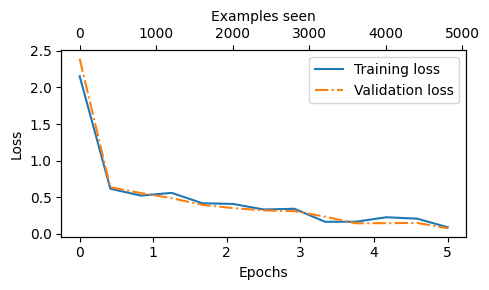

In [85]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen[-1], len(train_losses))
print(examples_seen)
train_losses = [x.to("cpu") for x in train_losses]
val_losses = [x.to("cpu") for x in val_losses]
plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

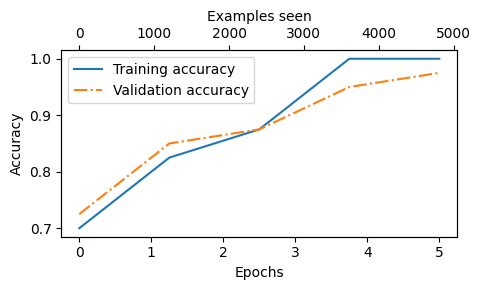

In [87]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen[-1], len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

Let's have a look at the accuracies for training, validation, and test datasets

In [89]:
train_accuracy = calculate_accuracy(train_dl, model, device)
val_accuracy = calculate_accuracy(val_dl, model, device)
test_accuracy = calculate_accuracy(test_dl, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 96.73%
Validation accuracy: 97.32%
Test accuracy: 96.00%


## 6.6: Using our model as a classifier

In [94]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    input_ids = tokenizer.encode(text)
    supported_context_length = model.positional_emb.weight.shape[0]

    # Truncate sequences if they too long
    input_ids = input_ids[:min(max_length, supported_context_length)]
    assert max_length is not None, (
        "max_length must be specified. If you want to use the full model context, "
        "pass max_length=model.pos_emb.weight.shape[0]."
    )
    assert max_length <= supported_context_length, (
        f"max_length ({max_length}) exceeds model's supported context length ({supported_context_length})."
    )    
    
    # Pad sequences to the longest sequence
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0) # add batch dimension

    # Model inference
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]  # Logits of the last output token
    predicted_label = torch.argmax(logits, dim=-1).item()

    # Return the classified result
    return "spam" if predicted_label == 1 else "not spam"

The above is a basic function for classification purposes. It formats our text, feeds it to the model and predicts label

In [104]:
text_1 = (
    "You have been randomly selected to receive an exclusive reward worth $500! Click the link below to claim your prize before it expires:"
)
print(classify_review(
    text_1, model, tokeniser, device, max_length=train_dataset.max_length
))

spam


In [97]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokeniser, device, max_length=train_dataset.max_length
))

not spam


Let's save our model now as learned before

In [108]:
torch.save(model.state_dict, "spam_classifier.pth")

If we want to load it later, we have the option to do so